## Exploratory Data Analysis 

This notebook presents my exploratory data analysis contribution to a five-person Netflix content strategy project.

The analysis uses a public Netflix Movies and TV Shows dataset to examine the structure of the catalog, the distribution of Movies and TV Shows, catalog growth over time, and the most common genre categories.

My contribution focused on dataset overview, data preparation, descriptive analysis, and visualization using pandas and Matplotlib. The goal was to establish an analytical baseline for the broader team project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

The dataset was downloaded from Kaggle and saved as `netflix_titles.csv`. It contains information about Netflix titles, including content type, title, country, date added, release year, rating, duration, and listed genres.

In [3]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Basic Dataset Structure

The following code checks the size of the dataset, column names, data types, and non-null counts. This helps us understand the structure of the data before analysis.

In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

df.info()

Dataset shape: (8807, 12)

Column names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Missing Values Check

Before cleaning the data, I checked missing values in each column. This helps identify which variables need preprocessing before EDA.

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

### Data Cleaning Preparation

The dataset was prepared for basic EDA by removing duplicate rows, converting `date_added` into datetime format, creating the `year_added` variable, and filling missing values in columns used for summary analysis.

In [6]:
df = df.drop_duplicates()

df["date_added"] = pd.to_datetime(df["date_added"].astype(str).str.strip(), errors="coerce")

df["year_added"] = df["date_added"].dt.year

df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["listed_in"] = df["listed_in"].fillna("Unknown")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


### Split Genre Column

One Netflix title can belong to multiple genres. Therefore, the `listed_in` column was split into separate genre rows. In this analysis, genre counts represent genre appearances rather than unique title counts.

In [7]:
genre_df = df.copy()

genre_df = genre_df.assign(
    genre=genre_df["listed_in"].str.split(", ")
).explode("genre")

genre_df["genre"] = genre_df["genre"].str.strip()

genre_df[["title", "type", "year_added", "genre"]].head(10)

,title,type,year_added,genre
0,Dick Johnson Is Dead,Movie,2021.0,Documentaries
1,Blood & Water,TV Show,2021.0,International TV Shows
1,Blood & Water,TV Show,2021.0,TV Dramas
1,Blood & Water,TV Show,2021.0,TV Mysteries
2,Ganglands,TV Show,2021.0,Crime TV Shows
2,Ganglands,TV Show,2021.0,International TV Shows
2,Ganglands,TV Show,2021.0,TV Action & Adventure
3,Jailbirds New Orleans,TV Show,2021.0,Docuseries
3,Jailbirds New Orleans,TV Show,2021.0,Reality TV
4,Kota Factory,TV Show,2021.0,International TV Shows


### Dataset Overview Summary

The following code summarizes the dataset size, content type counts, year range, number of genres, country entries, and rating categories.

In [8]:
print("Dataset shape:", df.shape)

print("\nContent type counts:")
print(df["type"].value_counts())

print("\nYear added range:")
print(int(df["year_added"].min()), "-", int(df["year_added"].max()))

print("\nNumber of unique genres:")
print(genre_df["genre"].nunique())

print("\nNumber of unique country entries:")
print(df["country"].nunique())

print("\nNumber of unique ratings:")
print(df["rating"].nunique())

Dataset shape: (8807, 13)

Content type counts:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Year added range:
2008 - 2021

Number of unique genres:
42

Number of unique country entries:
749

Number of unique ratings:
18


In [9]:
rating_counts = df["rating"].value_counts().head(10)

rating_counts

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

### Rating and Country Summary

The following code summarizes the most common rating categories and country entries. Missing country values labeled as `Unknown` are excluded from the top country summary.

In [10]:
top_countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)

top_countries

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

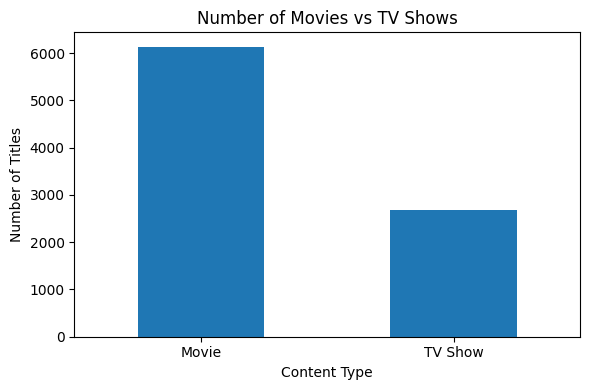

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [11]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(6, 4))
type_counts.plot(kind="bar")
plt.title("Number of Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("movie_vs_tv_show.png", dpi=300, bbox_inches="tight")
plt.show()

type_counts

**Interpretation:**  
As can be seen in the content type distribution chart, Movies are dominant in Netflix's catalog, which consists of 6,131 movies, while there are only 2,676 TV Shows. This indicates that the dataset is movie-heavy, something that needs to be kept in mind while analyzing further.

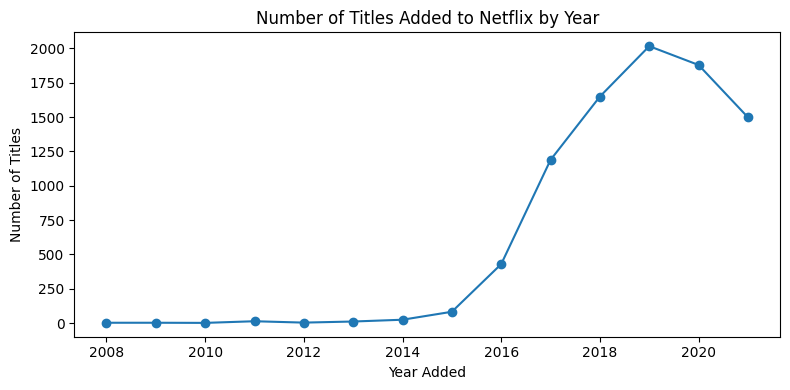

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64

In [12]:
titles_by_year = df.dropna(subset=["year_added"]).groupby("year_added").size()

plt.figure(figsize=(8, 4))
titles_by_year.plot(kind="line", marker="o")
plt.title("Number of Titles Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("titles_added_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

titles_by_year

**Interpretation:**  
Looking at the titles added to Netflix by year, it is evident that until 2015, there was slow growth but after that, there was a large increase of titles added each year. The year when maximum titles were added is 2019, when 2,016 titles were added. It seems that there was significant expansion of Netflix's content base during the late 2010s.

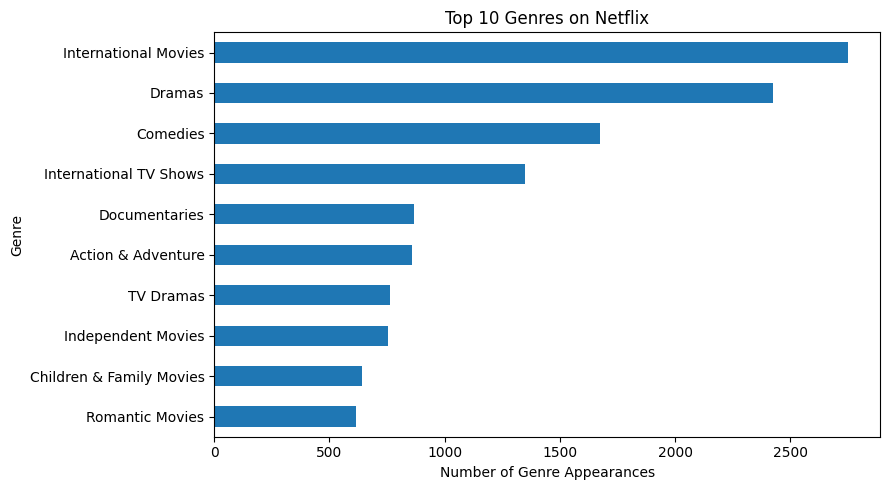

genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [13]:
top_genres = genre_df["genre"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_genres.sort_values().plot(kind="barh")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Genre Appearances")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("top_10_genres.png", dpi=300, bbox_inches="tight")
plt.show()

top_genres

**Interpretation:**  
As can be observed in the top genre chart, International Movies, Dramas, and Comedies are the topmost genres in the data set. As mentioned before, there could be multiple genres in one title so the numbers represent genre appearances and not unique title counts.

### Summary Table

The table below summarizes the main dataset information used in this basic EDA section.

In [14]:
summary_table = pd.DataFrame({
    "Metric": [
        "Total titles",
        "Movies",
        "TV Shows",
        "Year added range",
        "Unique genres"
    ],
    "Value": [
        len(df),
        df["type"].value_counts().get("Movie", 0),
        df["type"].value_counts().get("TV Show", 0),
        f"{int(df['year_added'].min())}-{int(df['year_added'].max())}",
        genre_df["genre"].nunique()
    ]
})

summary_table

,Metric,Value
0,Total titles,8807
1,Movies,6131
2,TV Shows,2676
3,Year added range,2008-2021
4,Unique genres,42


### Summary of Findings

The above basic exploratory analysis reveals three main observations. First, Netflix has many movies in its catalog. Second, there was sharp growth in Netflix's content after 2015, reaching a peak in 2019. Third, the most frequent genre categories are International Movies, Dramas, and Comedies.